In [3]:
import os
import sys
import anndata as ad
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import metacells as mc
from itertools import combinations

f_dir = os.path.dirname(os.path.abspath("__file__"))  
sys.path.append(os.path.abspath(os.path.join(f_dir, "..", "..", "utils")))

import constants
import utils

import tqdm 
import time

from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon, ks_2samp
from scipy.stats import chi2


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

2025-12-30 13:55:49.637849: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-30 13:55:49.671167: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
cells_ad = ad.read_h5ad(constants.CELLS_PATH)
metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']
gene_modules_dict = utils.load_pickle(constants.GENE_MODULES_DICT_PATH)

os.makedirs("./output", exist_ok=True)

## Figure 1B

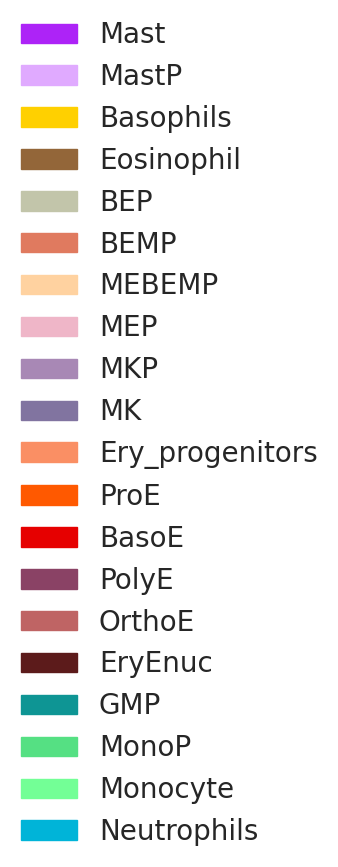

In [48]:
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in metacells_ad.obs.type.unique()}, ncol=1, output_path=os.path.join("./output", "1B_legend.pdf"))
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in metacells_ad.obs.type.unique()}, ncol=1)

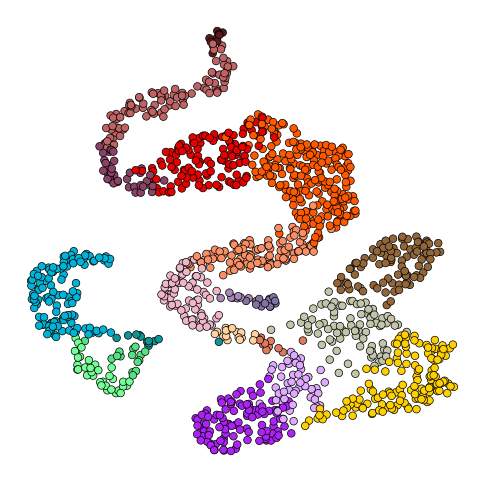

In [49]:
utils.plot_umap(metacells_ad, metadata_to_color="type", metadata_color_dict=cell_type_colors, figsize=(6,6), output_path=os.path.join("./output", "1B.pdf"), remove_legend=True)

## Figure 1C

In [5]:
lgc = utils.get_lgc(metacells_ad)
rlgc = lgc.sub(lgc.median(axis=0), axis=1)

In [6]:
# This is based on the MCView metacells order
metacells_order = utils.load_pickle("./metacells_order.pkl")

heatmap_markers_list = ["PRTN3","AIF1","MPO","ELANE","AZU1","S100A9","S100A8","MNDA","LYZ","MRC1","IFI30","S100B","FABP5","HBA2","HBA1","HBM",
                        "AHSP","APOC1","GAL","LAT","THBS1","PPBP","PF4","PDLIM1","GP1BB","MEF2C","HBD","PRG3","EPX","CPA3","CLC","HDC","GATA2","ALOX5AP","FCER1A","HPGD",
                        "HPGDS","TPSAB1","KRT1","AL157895.1","TPSB2",]

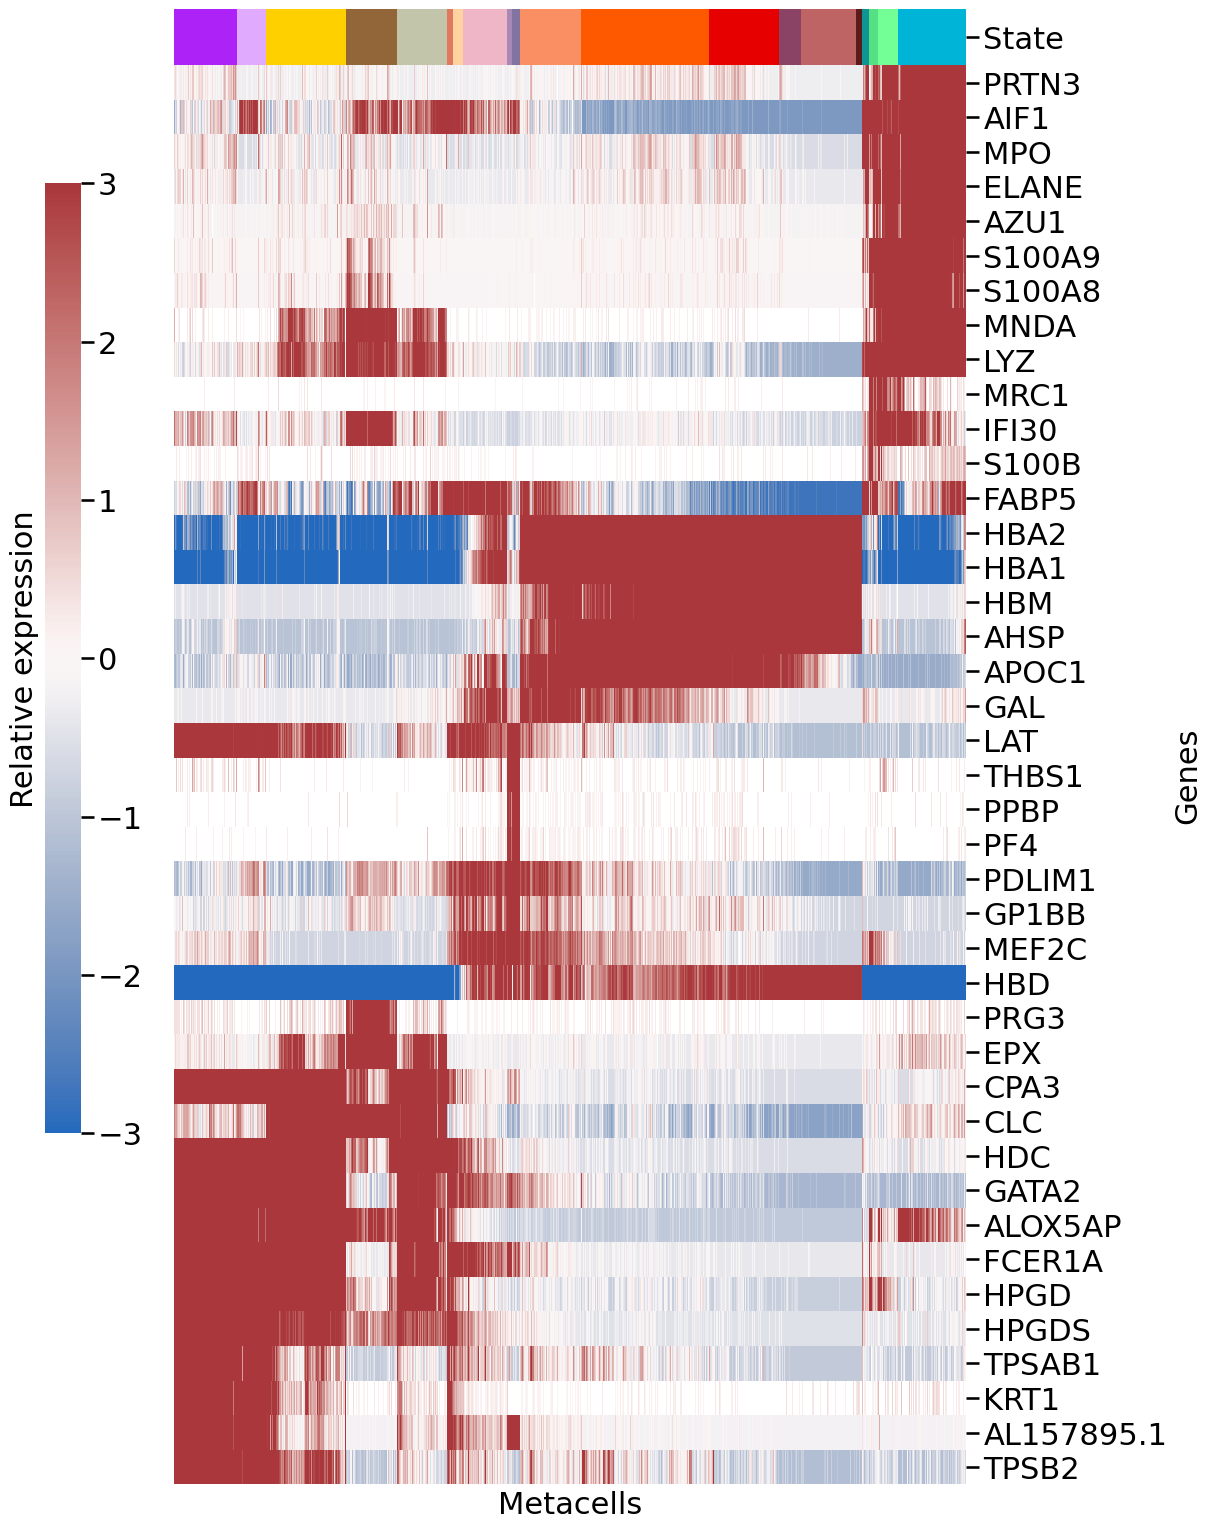

In [34]:

fontsize = 22
cell_type_cbar = metacells_ad[metacells_order].obs["type"].map(cell_type_colors)
cell_type_cbar.name = "State"
marker_heatmap = rlgc.loc[metacells_order, heatmap_markers_list].T

g = sb.clustermap(marker_heatmap, cmap="vlag", center=0, mask=marker_heatmap==0, vmin=-3, vmax=3, figsize=(12,19),
                            row_cluster=False, col_cluster=False,xticklabels=False, 
                            col_colors=cell_type_cbar, method="ward",cbar_pos=(0.08, 0.2, 0.03, 0.5),)

ax_col_colors = g.ax_col_colors
box = ax_col_colors.get_position()

# remove dendogrem lines
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Update tick font sizes
for ax in [g.ax_heatmap, g.ax_col_colors, g.ax_row_colors]:
    if ax is not None:
        ax.tick_params(labelsize=fontsize)

# Colorbar ticks
if g.cax is not None:
    g.cax.tick_params(labelsize=fontsize)
    g.cax.set_ylabel("Relative expression", fontsize=fontsize)
    g.cax.yaxis.set_label_position("left")

# Axis labels if visible (not xticklabels=False)
g.ax_heatmap.set_xlabel("Metacells", fontsize=fontsize)
g.ax_heatmap.set_ylabel("Genes", fontsize=fontsize)

plt.savefig("./output/1C.pdf", bbox_inches='tight', dpi=600)
plt.show()
plt.close()

## Figure S1A

In [12]:
from sklearn.neighbors import NearestNeighbors

In [13]:
mc.ut.set_o_data(cells_ad, "x",metacells_ad.obs.loc[cells_ad.obs.metacell_name].x.values)
mc.ut.set_o_data(cells_ad, "y",metacells_ad.obs.loc[cells_ad.obs.metacell_name].y.values)

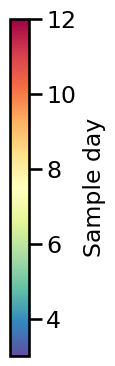

In [18]:
xy = np.c_[cells_ad.obs["x"].astype(float).values,
           cells_ad.obs["y"].astype(float).values]
z  = cells_ad.obs["sample_day_as_int"].astype(float).values  # cast once

# neighbors in 2D
k = 50# 30–80 is typical for UMAP-scale smoothing
nbrs = NearestNeighbors(n_neighbors=k).fit(xy)
dists, idx = nbrs.kneighbors(xy)

# Gaussian weights; sigma from kth-NN distance
sigma = np.median(dists[:, -1]) + 1e-12
W = np.exp(-(dists**2) / (2 * sigma**2))
W /= W.sum(axis=1, keepdims=True)

# 1) Continuous smoothing (weighted mean)
z_smooth = (W * z[idx]).sum(axis=1)

# 2) Discrete smoothing (weighted mode over integer days)
vals = z[idx].astype(int)
wmode = np.empty(len(z), dtype=int)
for i in range(len(z)):
    # aggregate weights per day
    w_by_day = {}
    for v, w in zip(vals[i], W[i]):
        w_by_day[v] = w_by_day.get(v, 0.0) + w
    wmode[i] = max(w_by_day.items(), key=lambda t: t[1])[0]

# choose what to plot:
#   z_smooth  -> smooth continuous pseudotime
#   wmode     -> smoothed discrete day labels
cells_ad.obs["day_smooth"] = z_smooth
cells_ad.obs["day_wmode"]  = wmode


plt.figure(figsize=(6,6))
utils.jitter(cells_ad.obs.x.astype(float), cells_ad.obs.y.astype(float), s=2, c=cells_ad.obs.day_smooth, alpha=0.5, jitter_size=0.01, cmap="Spectral_r")
plt.xticks([])
plt.yticks([])
plt.savefig("./output/S1A.pdf", bbox_inches='tight', dpi=600)

utils.plot_continuous_colorbar(vmin=3, vmax=12, cmap="Spectral_r", label="Sample day",
                               output_path="./output", filename="S1A_colorbar.pdf", labelpad=5)

## Figure S1C

In [12]:
trajectory_to_score = {
    "Mast":[("mast_dec_post_0", "Early Mast signature"), ("mast_inc_post_2","Late Mast signature")],
    "Ery":[("ery_dec_post_0", "Early Ery signature"), ("ery_inc_post_5","Late Ery signature")],
    "MK": [("mk_dec_post_0", "Early MK signature"), ("mk_inc_post_3","Late MK signature")],
    "Monocyte":[("monocyte_dec_post_0", "Early Monocyte signature"), ("monocyte_inc_post_1","Late Monocyte signature")],
    "Basophils": [("baso_dec_post_1", "Early Basophils signature"), ("baso_inc_post_2","Late Basophils signature")],
    "Neutrophils": [("neut_dec_post_0", "Early Neutrophils signature"), ("neut_inc_post_2","Late Neutrophils signature")],
    "Eosinophil": [("eosinophil_dec_post_0", "Early Eosinophil signature"), ("eosinophil_inc_post_1","Late Eosinophil signature")]
}

In [9]:
def rna_fraction_formatter(v, pos):
    if not float(v).is_integer():
        return ""
    return rf"$2^{{{int(v)}}}$"

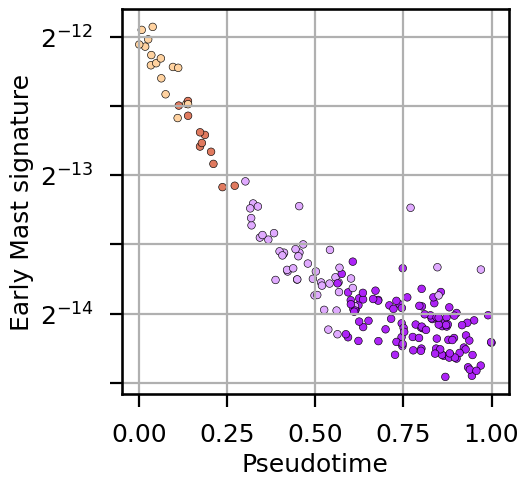

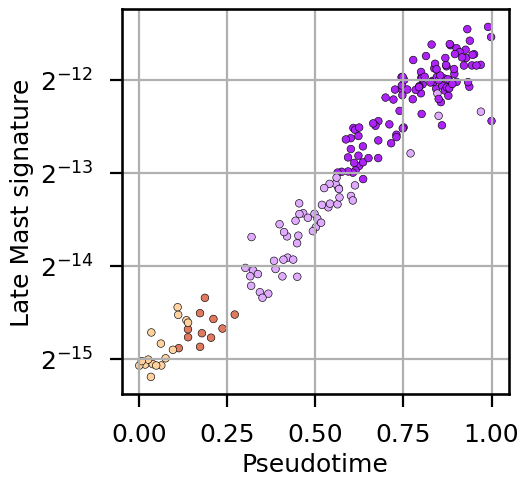

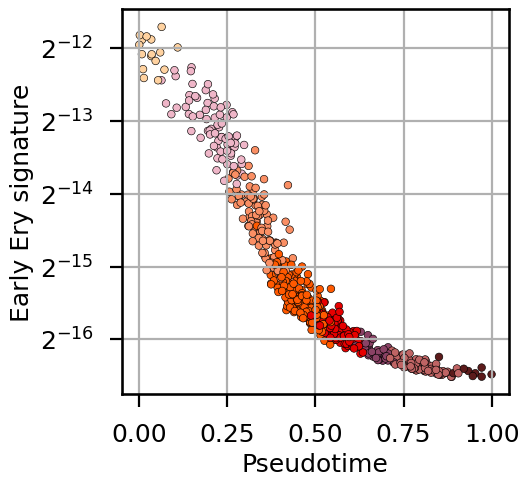

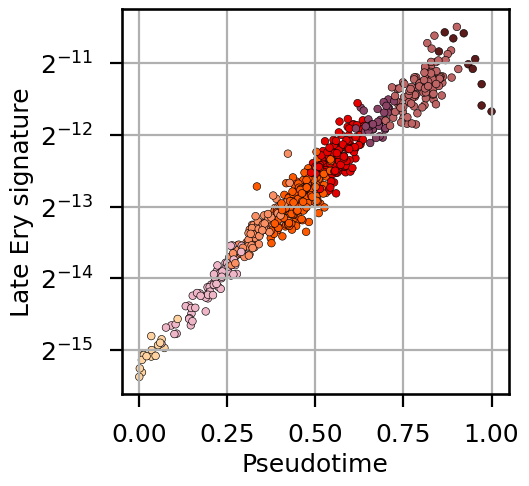

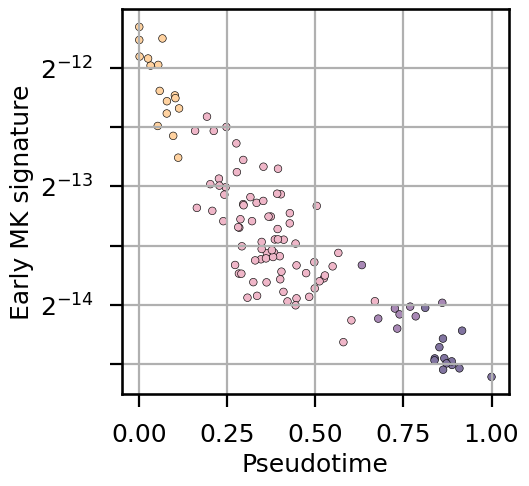

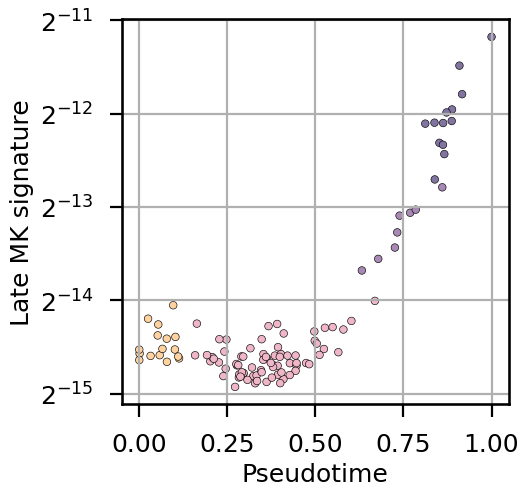

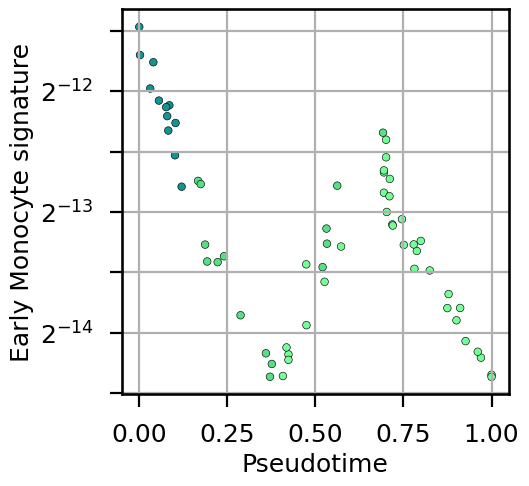

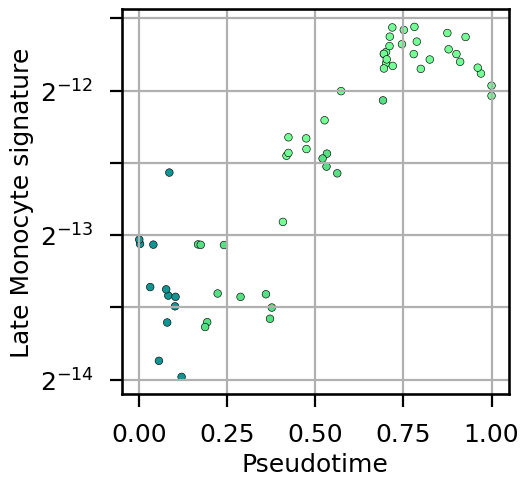

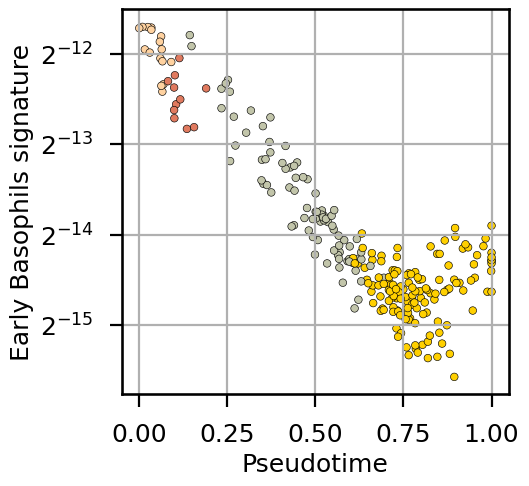

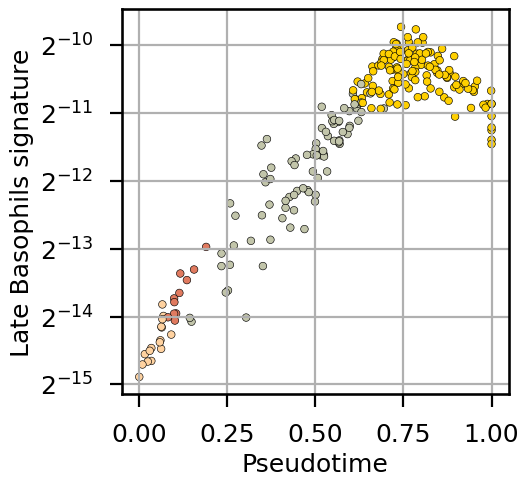

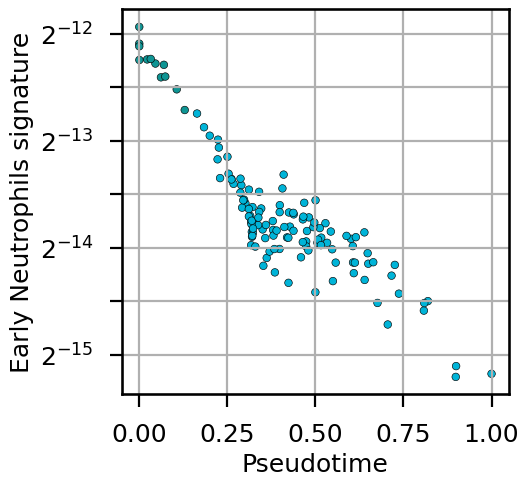

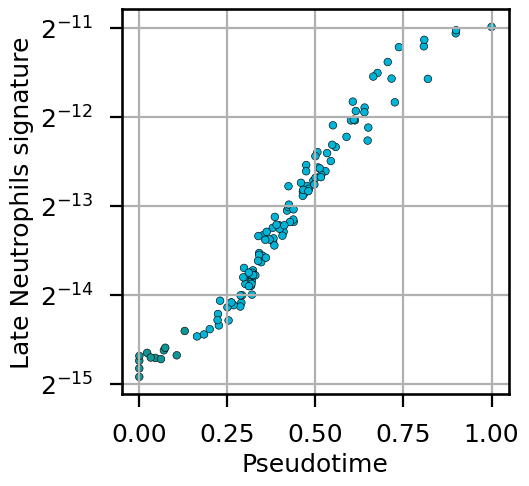

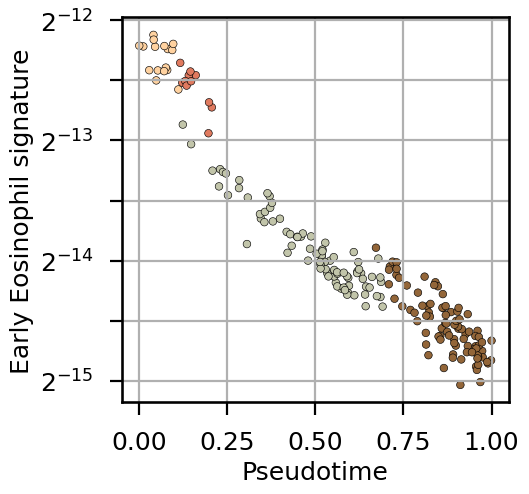

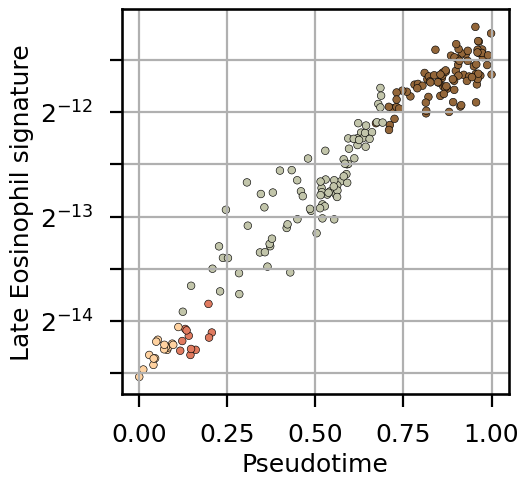

In [13]:
for trajectory in trajectory_to_score:
    scores_list = trajectory_to_score[trajectory]
    cell_types = constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]
    trajectory_mc = mc.ut.slice(metacells_ad,obs=metacells_ad.obs.top_level_cell_type.isin(cell_types))
    for m1,l1 in scores_list:
        utils.ggplot(trajectory_mc, m1="%s_pseudotime" %trajectory, m2=m1 + "_score",
                            label1= "Pseudotime", label2=l1, color_dict = cell_type_colors, legend=False, 
                            metadata_to_color = "type", figsize=5,
                            output_folder = os.path.join("./output"), file_prefix=f"S1C", yaxis_formatter=rna_fraction_formatter
        )

## QC tables

In [ ]:
df = cells_ad.obs


# ---------- Helpers ----------
def _clean_clone_id(s: pd.Series) -> pd.Series:
    """Drop null/placeholder clone ids."""
    if s.dtype.name == "category":
        s = s.astype(str)
    s = s.astype(object)
    bad = {"", "nan", "NaN", "None", "unknown", "Unknown"}
    return s.where(~s.isna() & ~s.astype(str).isin(bad), other=np.nan)

# ---------- Table 1: per exp_id → patients + (#cells per condition × sample_day_as_int) ----------
# Count cells per (exp_id, condition, sample_day_as_int)
counts = (
    df.groupby(["exp_id", "condition", "sample_day_as_int"], dropna=False)
      .size()
      .rename("n_cells")
      .reset_index()
)

# Wide layout: rows = exp_id; columns = (condition, day) with cell counts
cells_by_cond_day = (
    counts.pivot_table(
        index="exp_id",
        columns=["condition", "sample_day_as_int"],
        values="n_cells",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index(axis=1, level=[0, 1])  # sort by condition, then day
)


/tmp/ipykernel_930976/2498028486.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["exp_id", "condition", "sample_day_as_int"], dropna=False)
/tmp/ipykernel_930976/2498028486.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts.pivot_table(
/tmp/ipykernel_930976/2498028486.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("exp_id")["patient"]


In [14]:
cells_with_clones = mc.ut.slice(cells_ad, obs=(cells_ad.obs.clone_id.notna() & (cells_ad.obs.clone_id != "nan")))
cells_with_clones_with_enough_data = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.clone_exp_id.isin(cells_with_clones.obs.clone_exp_id.value_counts()[cells_with_clones.obs.clone_exp_id.value_counts() > 1].index))

In [15]:
clones_condition_sample_days = cells_with_clones_with_enough_data.obs.groupby(["clone_exp_id", "sample_day_as_int"], observed=True).agg({"condition":"first", "top_level_cell_type":"count"}).reset_index()
clones_condition_sample_days.to_csv("./output/clones_condition_sample_days.tsv", sep="\t", index=False)

In [73]:
cells_ad.obs.groupby(["exp_id","condition","sample_day_as_int"], observed=True).agg({"clone_exp_id":"nunique", "clone_id":"size"}).to_csv("./output/cells_by_condition_and_day.tsv", sep="\t")

In [74]:
cells_ad.obs.groupby("condition", observed=True).agg({"clone_exp_id":"nunique", "clone_id":"size"}).to_csv("./output/cells_by_condition.tsv", sep="\t")